# 03 - Kernel cuántico con Pytket

Inspección de mapas de características, recursos y propiedades matemáticas de los kernels exactos.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import HTML, Image, display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'results/latest_run.json').exists())
latest = json.loads((ROOT / 'results/latest_run.json').read_text(encoding='utf-8'))
RUN = ROOT / latest['path']
ranking = pd.read_csv(RUN / 'metrics/feature_map_ranking.csv')
display(ranking.round(4))

,feature_map,cv_f1_mean,cv_f1_std_across_subsets,balanced_accuracy_mean,kernel_target_alignment_mean,effective_rank_mean
0,custom,0.5648,0.0960,0.5302,0.1832,36.3163
1,zz,0.5521,0.1072,0.5365,0.1493,24.3703
2,pauli,0.4532,0.1532,0.4958,0.1330,20.5735


In [2]:
for name in ['custom', 'zz', 'pauli']:
    diag = json.loads((RUN / f'metrics/kernel_diagnostics_{name}.json').read_text(encoding='utf-8'))
    keys = ['symmetry_max_abs_error', 'diagonal_max_abs_error', 'minimum_eigenvalue', 'effective_rank', 'kernel_target_alignment']
    print(name, {k: diag[k] for k in keys})

custom {'symmetry_max_abs_error': 3.885780586188048e-16, 'diagonal_max_abs_error': 3.9968028886505635e-15, 'minimum_eigenvalue': 0.4796698776296951, 'effective_rank': 60.95653570420879, 'kernel_target_alignment': 0.11795631268620499}
zz {'symmetry_max_abs_error': 1.7208456881689926e-15, 'diagonal_max_abs_error': 5.773159728050814e-15, 'minimum_eigenvalue': 0.25164668311775673, 'effective_rank': 34.766489140785765, 'kernel_target_alignment': 0.0726206603716489}
pauli {'symmetry_max_abs_error': 8.881784197001252e-16, 'diagonal_max_abs_error': 6.217248937900877e-15, 'minimum_eigenvalue': 0.21668166814035056, 'effective_rank': 27.503998993606867, 'kernel_target_alignment': 0.07624940337929352}


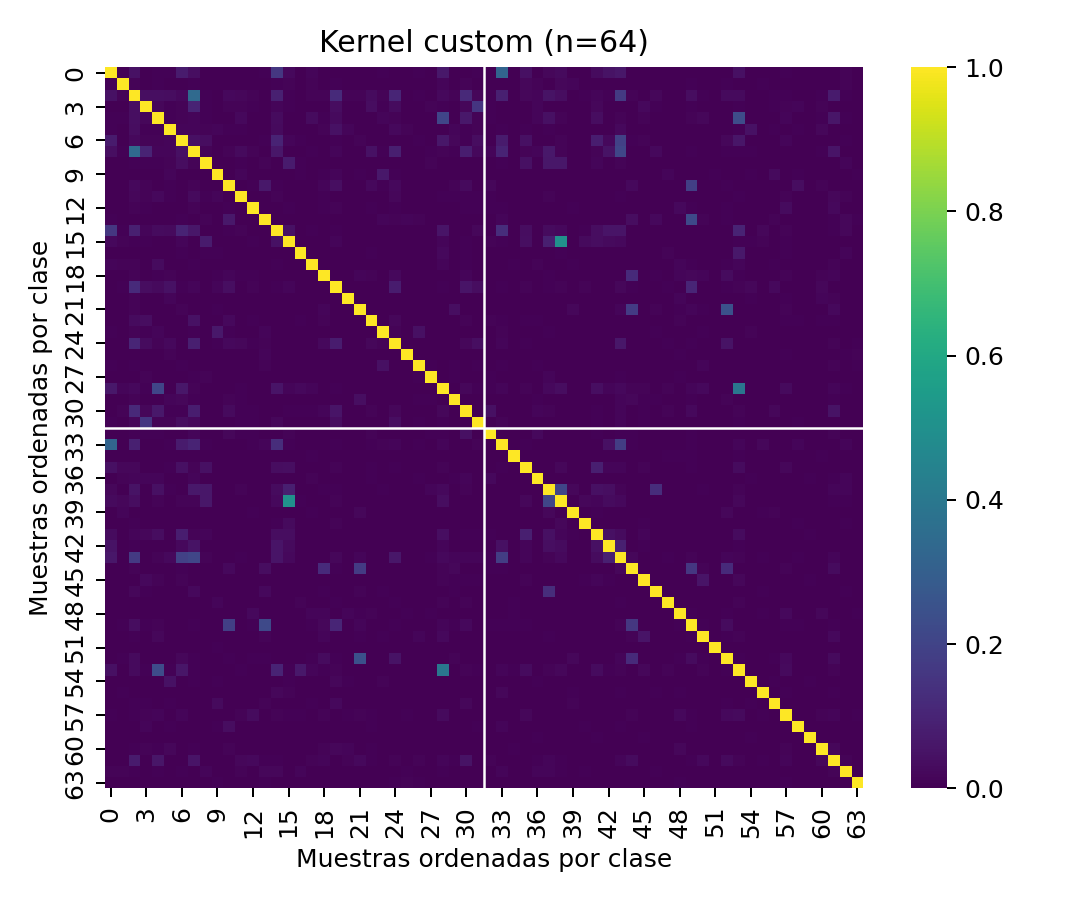

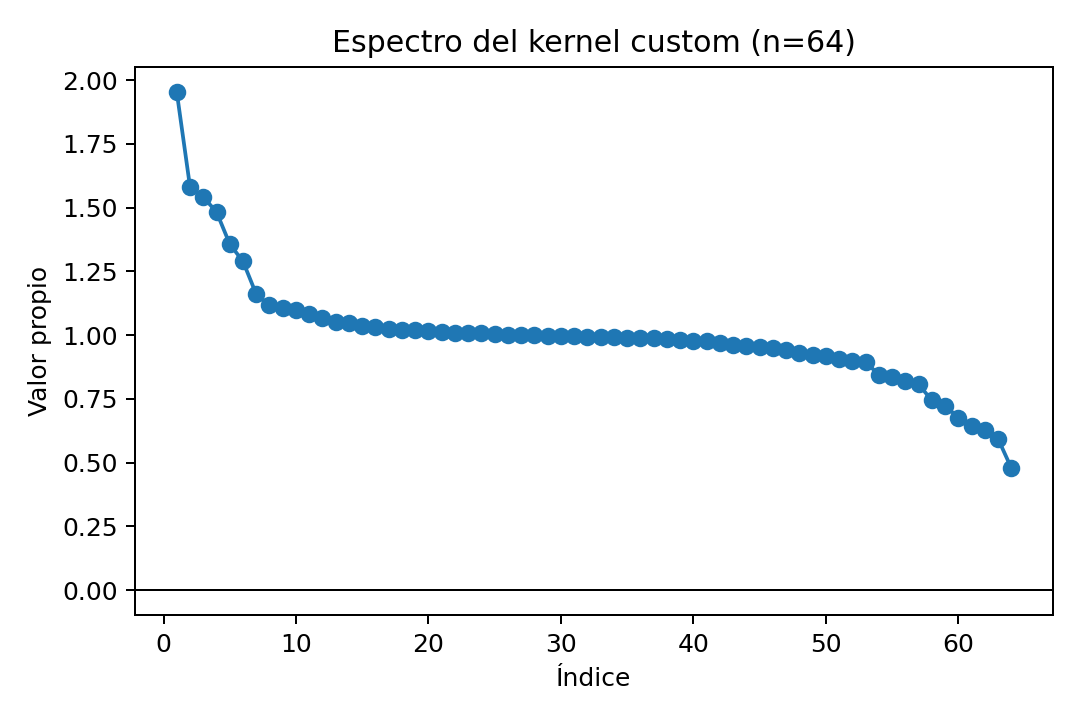

In [3]:
display(Image(filename=str(RUN / 'figures/kernel_heatmap_custom.png'), width=650))
display(Image(filename=str(RUN / 'figures/kernel_spectrum_custom.png'), width=650))
display(HTML(f'<a href="{(RUN / "circuits/feature_map_custom.html").as_uri()}" target="_blank">Abrir circuito interactivo custom</a>'))

El mapa `custom` se eligió exclusivamente con CV en entrenamiento. Los kernels se validaron por simetría, diagonal unitaria, rango numérico y espectro PSD antes de alimentar la QSVM.